In [1]:
%run ./00_setup.ipynb
leases = pd.read_parquet(INTERIM_DIR / "leases.parquet")
mix_yearly = pd.read_parquet(INTERIM_DIR / "mix_yearly.parquet")

listings      1,061 rows  29 columns
leases        4,302 rows  35 columns
concessions   3,560 rows  18 columns
asking        3,857 rows  14 columns
Columns dropped from leases: ['available_date', 'property_type', 'furnishing', 'smoking', 'cats_allowed', 'dogs_allowed']
leases: 4,302 rows, 33 columns


## 4. Comparing each apartment with itself: same-apartment pairs

### 4.1 Matching each lease with the previous lease of the same apartment
We sort the leases by `UNIT_KEY` (`prop_code`, `unit_code`) then by `lease_start`, and attach to each lease
the values of the previous lease **of the same apartment** (`prev_*`). An apartment's first lease has no previous lease, so it is dropped.
Same apartment, same building, same floor area: the only thing left to change is the price. That's the whole idea.

In [2]:
PAIR_CARRY_COLS = ["lease_start", "lease_end", "rent_contract", "rent_effective", "concession_depth"]


def build_lease_pairs(lease_table):
    """Match each lease with the previous lease of the same apartment (key UNIT_KEY).

    Input: renamed lease table. Output: one row per lease that has a previous lease,
    with the prev_* columns and the gap in years between the two lease starts.
    """
    ordered = lease_table.sort_values(UNIT_KEY + ["lease_start"]).copy()
    previous = ordered.groupby(UNIT_KEY)[PAIR_CARRY_COLS].shift(1).add_prefix("prev_")
    candidate_pairs = pd.concat([ordered, previous], axis=1).dropna(subset=["prev_lease_start"])
    candidate_pairs["gap_years"] = (candidate_pairs.lease_start - candidate_pairs.prev_lease_start).dt.days / DAYS_PER_YEAR
    candidate_pairs["days_between_leases"] = (candidate_pairs.lease_start - candidate_pairs.prev_lease_end).dt.days
    return candidate_pairs


candidate_pairs = build_lease_pairs(leases)
print(f"{len(leases):,} leases -> {len(candidate_pairs):,} candidate pairs "
      f"({leases.groupby(UNIT_KEY).ngroups:,} first leases with no previous lease)")
print("Overlaps (previous lease ends after the next one starts):",
      int((candidate_pairs.days_between_leases < 0).sum()))

4,302 leases -> 3,241 candidate pairs (1,061 first leases with no previous lease)
Overlaps (previous lease ends after the next one starts): 0


### 4.2 Which date defines the gap between two leases?
We look at the distribution of the gap between the **starts** of two consecutive leases.
Why the start date? It's the date the new rent takes effect; the start-to-start gap is one year for a
standard renewal. No lease overlaps the next one (checked above), so the chronological order is reliable.

In [3]:
GAP_DISPLAY_BINS = [0, MIN_GAP_YEARS, *GAP_DISPLAY_EDGES, MAX_GAP_YEARS, np.inf]
pd.cut(candidate_pairs.gap_years, GAP_DISPLAY_BINS).value_counts().sort_index().to_frame("pairs")

,pairs
gap_years,
"(0.0, 0.5]",62
"(0.5, 0.9]",10
"(0.9, 1.1]",2789
"(1.1, 1.5]",335
"(1.5, 2.5]",45
"(2.5, inf]",0


### 4.3 Filtering out non-comparable pairs
We keep pairs whose gap is strictly between `MIN_GAP_YEARS` (0.5 year) and `MAX_GAP_YEARS` (2.5 years),
with strictly positive rents.
Why those bounds: under 0.5 year it's usually a short lease or the same lease entered twice (and the annualised change
blows up); over 2.5 years the change mixes several years of market movement.

In [4]:
def filter_comparable_pairs(candidate_pairs, min_gap=MIN_GAP_YEARS, max_gap=MAX_GAP_YEARS):
    """Keep pairs with a gap in ]min_gap, max_gap[ years and positive rents."""
    keep = (candidate_pairs.gap_years.between(min_gap, max_gap, inclusive="neither")
            & (candidate_pairs.prev_rent_contract > 0) & (candidate_pairs.rent_contract > 0))
    return candidate_pairs[keep].copy()


comparable_pairs = filter_comparable_pairs(candidate_pairs)
removed = len(candidate_pairs) - len(comparable_pairs)
print(f"{len(candidate_pairs):,} -> {len(comparable_pairs):,} pairs ({removed} removed, {removed / len(candidate_pairs):.1%})")

3,241 -> 3,179 pairs (62 removed, 1.9%)


### 4.4 Annualising the change
The formula: `growth = (rent / previous rent) ^ (1 / gap_in_years) − 1`, for contract **and** effective rent.
A 6 % increase over 18 months isn't 6 % a year, so we annualise to put every pair on the same footing.

In [5]:
def annualized_growth(current, previous, gap_years):
    """Compound yearly growth rate between two rents gap_years years apart (fraction)."""
    return (current / previous) ** (1 / gap_years) - 1


def add_pair_growth(comparable_pairs):
    """Add growth_contract and growth_effective (annualised fractions)."""
    with_growth = comparable_pairs.copy()
    for basis in ("contract", "effective"):
        with_growth[f"growth_{basis}"] = annualized_growth(
            with_growth[f"rent_{basis}"], with_growth[f"prev_rent_{basis}"], with_growth.gap_years)
    return with_growth


LEASE_PAIR_COLS = ["unit_id", "prop_code", "unit_code", "building", "province", "bedrooms", "lease_year",
                   "lease_type", "is_renewal", "gap_years", "rent_contract", "prev_rent_contract",
                   "rent_effective", "prev_rent_effective", "concession_depth", "prev_concession_depth",
                   "growth_contract", "growth_effective"]
lease_pairs = add_pair_growth(comparable_pairs)[LEASE_PAIR_COLS].reset_index(drop=True)
print(f"{len(lease_pairs):,} pairs over {lease_pairs.unit_id.nunique():,} apartments")

3,179 pairs over 890 apartments


### 4.5 Same-apartment growth per year
The median growth rate per start year of the new lease (the median, so a few odd pairs can't drive it), with the number of pairs `n`.

In [6]:
same_unit_yearly = lease_pairs.groupby("lease_year").agg(
    pairs=("growth_contract", "size"),
    median_contract=("growth_contract", "median"),
    median_effective=("growth_effective", "median"),
    mean_contract=("growth_contract", "mean"),
)
(same_unit_yearly.drop(columns="pairs") * PCT).round(2).assign(pairs=same_unit_yearly.pairs)

,median_contract,median_effective,mean_contract,pairs
lease_year,,,,
2018,2.47,1.98,2.13,88
2019,2.14,1.63,2.00,159
2020,3.17,3.02,3.03,331
2021,4.46,3.54,4.38,355
2022,5.40,4.59,5.27,352
2023,2.29,2.02,2.09,416
2024,3.39,1.77,3.73,698
2025,7.04,3.58,7.56,780


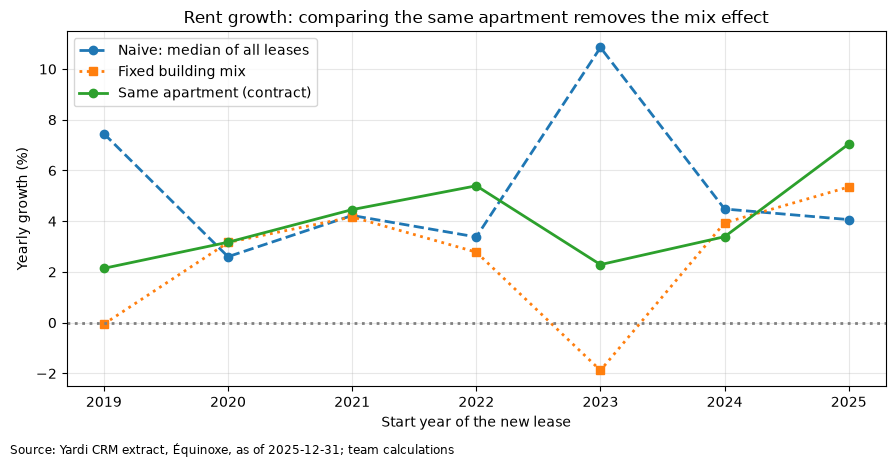

In [7]:
fig, ax = plt.subplots(figsize=FIGSIZE)
years_shown = same_unit_yearly.index[same_unit_yearly.index >= FIRST_ANALYSIS_YEAR + 1]
ax.plot(years_shown, mix_yearly.loc[years_shown, "naive_growth"] * PCT, "o--", label="Naive: median of all leases")
ax.plot(years_shown, mix_yearly.loc[years_shown, "fixed_building_growth"] * PCT, "s:", label="Fixed building mix")
ax.plot(years_shown, same_unit_yearly.loc[years_shown, "median_contract"] * PCT, "o-", label="Same apartment (contract)")
ax.axhline(0, color="grey", linestyle=":")
ax.set_title("Rent growth: comparing the same apartment removes the mix effect")
ax.set_xlabel("Start year of the new lease")
ax.set_ylabel("Yearly growth (%)")
ax.legend()
add_source(fig)
plt.tight_layout()
plt.show()

### 4.6 Sensitivity to the filtering choices
We recompute the yearly contract median with other gap bounds (`GAP_SENSITIVITY_BOUNDS`) and with the mean instead of the median.
If the answer swung a lot with an arbitrary threshold, we'd have a problem. It barely moves (pairs with a gap of ≈ 1 year are the vast majority).

In [8]:
sensitivity = {}
for min_gap, max_gap in GAP_SENSITIVITY_BOUNDS:
    variant = add_pair_growth(filter_comparable_pairs(candidate_pairs, min_gap, max_gap))
    sensitivity[f"median, gap ]{min_gap}, {max_gap}["] = variant.groupby("lease_year").growth_contract.median()
sensitivity["mean (base bounds)"] = lease_pairs.groupby("lease_year").growth_contract.mean()
(pd.DataFrame(sensitivity).loc[FIRST_ANALYSIS_YEAR:] * PCT).round(2)

,"median, gap ]0.75, 1.5[","median, gap ]0.9, 1.1[","median, gap ]0.5, 2.5[",mean (base bounds)
lease_year,,,,
2018,2.50,2.66,2.47,2.13
2019,2.14,2.27,2.14,2.00
2020,3.20,3.30,3.17,3.03
2021,4.49,4.54,4.46,4.38
2022,5.45,5.55,5.40,5.27
2023,2.30,2.33,2.29,2.09
2024,3.42,3.51,3.39,3.73
2025,7.09,7.13,7.04,7.56


In [9]:
lease_pairs.to_parquet(INTERIM_DIR / "lease_pairs.parquet")